# Task 1：German Loan Default Prediction

1.IMPORTS & SETUP

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    recall_score, precision_score, balanced_accuracy_score,
    accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import clone

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')
# Reproducibility
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED) 

print('All imports successful.')
print(f'TensorFlow version: {tf.__version__}')

All imports successful.
TensorFlow version: 2.21.0


2: LOAD DATA & BASIC EXPLORATION

In [45]:
df = pd.read_csv('German_bank.csv')

print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum().sum()}')
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'\nTarget distribution:\n{df["default"].value_counts()}')
print(f'\nTarget proportion:\n{df["default"].value_counts(normalize=True)}')
df.head()

Shape: (1000, 17)

Column dtypes:
checking_balance        object
months_loan_duration     int64
credit_history          object
purpose                 object
amount                   int64
savings_balance         object
employment_duration     object
percent_of_income        int64
years_at_residence       int64
age                      int64
other_credit            object
housing                 object
existing_loans_count     int64
job                     object
dependents               int64
phone                   object
default                 object
dtype: object

Missing values:
0

Duplicates: 0

Target distribution:
default
no     700
yes    300
Name: count, dtype: int64

Target proportion:
default
no     0.7
yes    0.3
Name: proportion, dtype: float64


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


3. FEATURE CLASSIFICATION & BASIC STATISTICS

In [46]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('default')  # target is not a feature

print(f'Numerical features ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

print('\n--- Numerical Feature Statistics ---')
display(df[numerical_cols].describe())

print('\n--- Categorical Feature Value Counts ---')
for col in categorical_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())

Numerical features (7): ['months_loan_duration', 'amount', 'percent_of_income', 'years_at_residence', 'age', 'existing_loans_count', 'dependents']
Categorical features (9): ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_duration', 'other_credit', 'housing', 'job', 'phone']

--- Numerical Feature Statistics ---


,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000



--- Categorical Feature Value Counts ---

checking_balance:
checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64

credit_history:
credit_history
good         530
critical     293
poor          88
very good     49
perfect       40
Name: count, dtype: int64

purpose:
purpose
furniture/appliances    473
car                     337
business                 97
education                59
renovations              22
car0                     12
Name: count, dtype: int64

savings_balance:
savings_balance
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64

employment_duration:
employment_duration
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: count, dtype: int64

other_credit:
other_credit
none     814
bank     139
store     47
Name: count, dtype: int64

housing:
housing
own      713
rent     179
othe

4. EXPLORATORY DATA ANALYSIS - VISUALIZATIONS

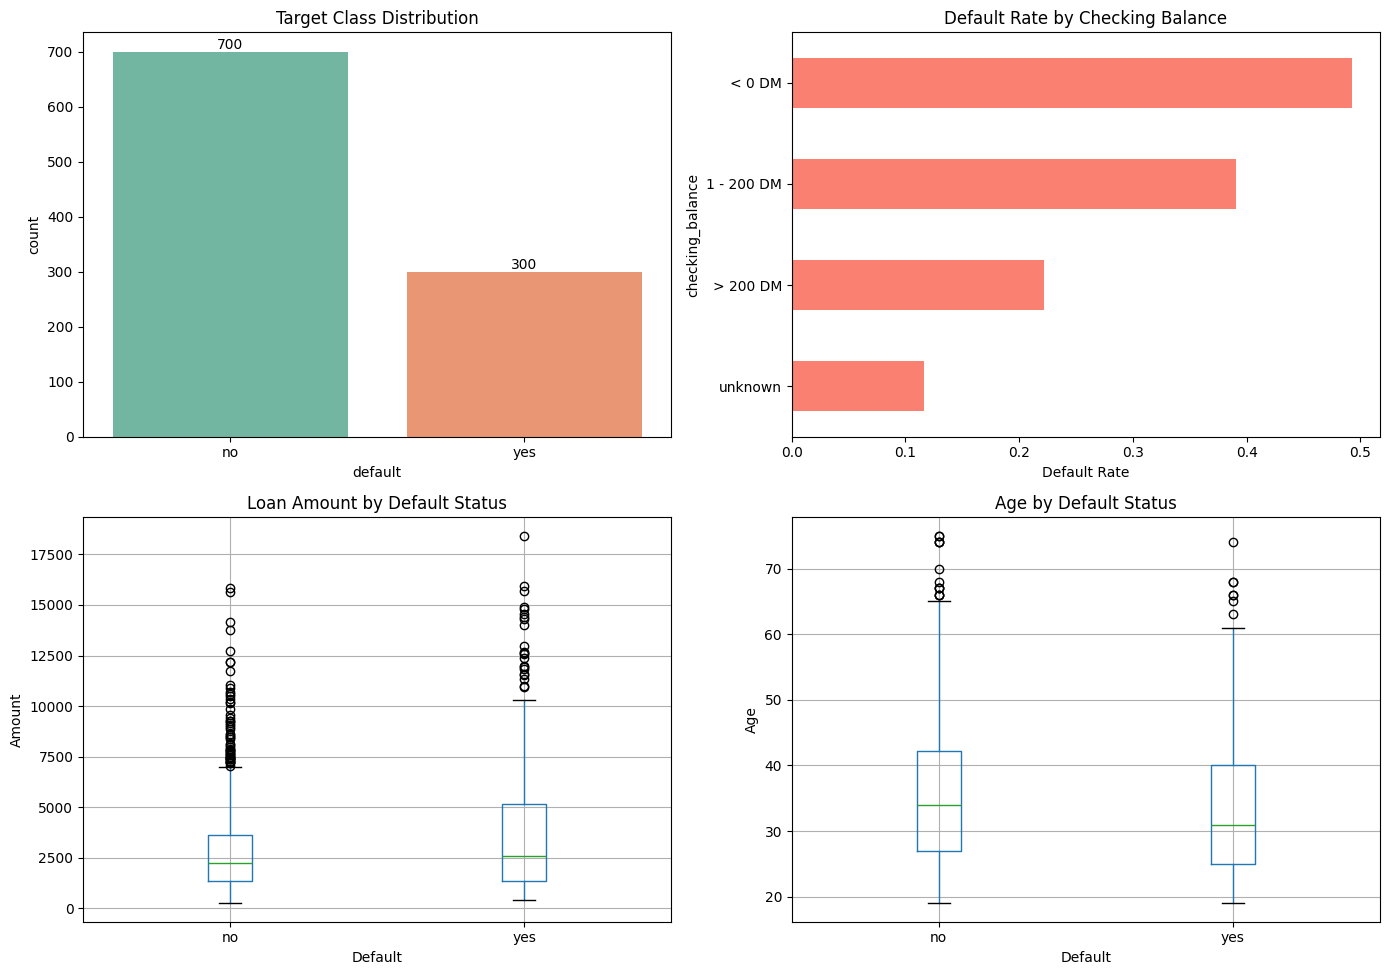

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target class distribution
sns.countplot(x='default', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Target Class Distribution')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom')

# 2. Default rate by checking_balance
ct = pd.crosstab(df['checking_balance'], df['default'], normalize='index')
ct['yes'].sort_values().plot(kind='barh', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Default Rate by Checking Balance')
axes[0, 1].set_xlabel('Default Rate')

# 3. Amount distribution by default status
df.boxplot(column='amount', by='default', ax=axes[1, 0])
axes[1, 0].set_title('Loan Amount by Default Status')
axes[1, 0].set_xlabel('Default')
axes[1, 0].set_ylabel('Amount')
plt.suptitle('')  # remove auto title

# 4. Age distribution by default status
df.boxplot(column='age', by='default', ax=axes[1, 1])
axes[1, 1].set_title('Age by Default Status')
axes[1, 1].set_xlabel('Default')
axes[1, 1].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

5. DATA PREPROCESSING - ENCODER SETUP

In [48]:
# Separate features and target
X = df.drop('default', axis=1)
y = df['default'].map({'no': 0, 'yes': 1}).values  # encode target: no=0, yes=1

print(f'X shape: {X.shape}')
print(f'y distribution: {np.bincount(y)}  (0=no, 1=yes)')

# Build preprocessor
# This preprocessor definition will be:
# - Cloned and fit separately in each CV fold (MLP)
# - Cloned inside the RF Pipeline for each fold
# - Fit on full X_train for test-time use
# - Ensure no data leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

print('\nPreprocessor configured.')

X shape: (1000, 16)
y distribution: [700 300]  (0=no, 1=yes)

Preprocessor configured.


6. TRAIN/TEST SPLIT & CLASS WEIGHTS

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')
print(f'Train target distribution: {np.bincount(y_train)}')
print(f'Test target distribution:  {np.bincount(y_test)}')

# Compute class weights on TRAIN only
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}
print(f'\nClass weights (train only): {class_weight_dict}')

Train: 700 samples, Test: 300 samples
Train target distribution: [490 210]
Test target distribution:  [210  90]

Class weights (train only): {0: np.float64(0.7142857142857143), 1: np.float64(1.6666666666666667)}


7. MLP - BUILD FUNCTION & CANDIDATE DEFINITIONS

In [50]:
def build_mlp(architecture, input_dim):
    """Build MLP model.
    Architecture A: 64 -> 32 (conservative)
    Architecture B: 128 -> 64 (standard)
    """
    model = keras.Sequential(name=f'MLP_Candidate_{architecture}')
    model.add(layers.Input(shape=(input_dim,)))

    if architecture == 'A':
        model.add(layers.Dense(64, activation='relu',
                               kernel_regularizer=regularizers.l2(0.001)))
        model.add(layers.Dropout(0.3))
        model.add(layers.Dense(32, activation='relu',
                               kernel_regularizer=regularizers.l2(0.001)))
        model.add(layers.Dropout(0.3))
    elif architecture == 'B':
        model.add(layers.Dense(128, activation='relu',
                               kernel_regularizer=regularizers.l2(0.001)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(64, activation='relu',
                               kernel_regularizer=regularizers.l2(0.001)))
        model.add(layers.Dropout(0.3))
    
    model.add(layers.Dense(2, activation='softmax'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

8: MLP - 5-FOLD CV FOR ARCHITECTURE SELECTION

In [51]:
cv_results_mlp = {'A': [], 'B': []}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for arch in ['A', 'B']:
    print(f'\n=== Evaluating MLP Candidate {arch} ===')
    fold_f1_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        # Raw fold split
        X_fold_train_raw = X_train.iloc[train_idx]
        X_fold_val_raw = X_train.iloc[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        # Fit preprocessing INSIDE this fold only
        preprocessor_fold = clone(preprocessor)
        X_fold_train = preprocessor_fold.fit_transform(X_fold_train_raw)
        X_fold_val = preprocessor_fold.transform(X_fold_val_raw)

        # Fold-specific class weights
        class_weights_fold = compute_class_weight(
            class_weight='balanced',
            classes=np.array([0, 1]),
            y=y_fold_train
        )
        class_weight_dict_fold = {
            0: class_weights_fold[0],
            1: class_weights_fold[1]
        }
        sw_fold = np.array([class_weight_dict_fold[label] for label in y_fold_train])

        # Build model with fold-specific input_dim
        model = build_mlp(arch, input_dim=X_fold_train.shape[1])

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        )

        model.fit(
            X_fold_train, y_fold_train,
            epochs=100,
            batch_size=32,
            validation_data=(X_fold_val, y_fold_val),
            sample_weight=sw_fold,
            callbacks=[early_stop],
            verbose=0
        )

        y_fold_pred = np.argmax(model.predict(X_fold_val, verbose=0), axis=1)
        fold_f1 = f1_score(y_fold_val, y_fold_pred, average='macro')
        fold_f1_scores.append(fold_f1)
        print(f'  Fold {fold_idx + 1}: F1 = {fold_f1:.4f}')

    cv_results_mlp[arch] = fold_f1_scores
    print(f'  Mean F1: {np.mean(fold_f1_scores):.4f} (+/- {np.std(fold_f1_scores):.4f})')

# Select best architecture
mean_a = np.mean(cv_results_mlp['A'])
mean_b = np.mean(cv_results_mlp['B'])
best_arch = 'A' if mean_a >= mean_b else 'B'
print(f'\n>>> Best MLP architecture: Candidate {best_arch} (Mean F1: {max(mean_a, mean_b):.4f})')


=== Evaluating MLP Candidate A ===
  Fold 1: F1 = 0.6575
  Fold 2: F1 = 0.6988
  Fold 3: F1 = 0.6875
  Fold 4: F1 = 0.6699
  Fold 5: F1 = 0.6988
  Mean F1: 0.6825 (+/- 0.0164)

=== Evaluating MLP Candidate B ===
  Fold 1: F1 = 0.6953
  Fold 2: F1 = 0.6924
  Fold 3: F1 = 0.6832
  Fold 4: F1 = 0.6520
  Fold 5: F1 = 0.6600
  Mean F1: 0.6766 (+/- 0.0174)

>>> Best MLP architecture: Candidate A (Mean F1: 0.6825)


9. MLP - FINAL TRAINING WITH FAIR FULL-TRAIN REFIT

In [52]:
# Stage 1: use subtrain/val to determine best epoch
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

print(f'Subtrain: {X_subtrain.shape[0]} samples, Validation: {X_val.shape[0]} samples')
print(f'Subtrain target distribution: {np.bincount(y_subtrain)}')
print(f'Validation target distribution: {np.bincount(y_val)}')

# Fit preprocessor on SUBTRAIN only
preprocessor_subtrain = clone(preprocessor)
X_subtrain_processed = preprocessor_subtrain.fit_transform(X_subtrain)
X_val_processed = preprocessor_subtrain.transform(X_val)

print(f'\nProcessed subtrain shape: {X_subtrain_processed.shape}')
print(f'Processed validation shape: {X_val_processed.shape}')

# Class weights for subtrain only
class_weights_subtrain = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_subtrain
)
class_weight_dict_subtrain = {
    0: class_weights_subtrain[0],
    1: class_weights_subtrain[1]
}
sample_weights_subtrain = np.array([class_weight_dict_subtrain[label] for label in y_subtrain])

print(f'\nClass weights (subtrain only): {class_weight_dict_subtrain}')

# Train provisional model to determine best epoch
mlp_temp = build_mlp(best_arch, input_dim=X_subtrain_processed.shape[1])

early_stop_temp = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = mlp_temp.fit(
    X_subtrain_processed, y_subtrain,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_processed, y_val),
    sample_weight=sample_weights_subtrain,
    callbacks=[early_stop_temp],
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'\nBest epoch based on validation loss: {best_epoch}')

# Stage 2: refit final model on FULL X_train
final_preprocessor = clone(preprocessor)
X_train_processed = final_preprocessor.fit_transform(X_train)
X_test_processed = final_preprocessor.transform(X_test)

print(f'\nProcessed full-train shape: {X_train_processed.shape}')
print(f'Processed test shape: {X_test_processed.shape}')

# Full-train class weights
class_weights_full = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict_full = {
    0: class_weights_full[0],
    1: class_weights_full[1]
}
sample_weights_train = np.array([class_weight_dict_full[label] for label in y_train])

print(f'Class weights (full train): {class_weight_dict_full}')

# Final refit using all training data and fixed best_epoch
mlp_final = build_mlp(best_arch, input_dim=X_train_processed.shape[1])

mlp_final.fit(
    X_train_processed, y_train,
    epochs=best_epoch,
    batch_size=32,
    sample_weight=sample_weights_train,
    verbose=1
)

print(f'\nFinal MLP retrained on full training set for {best_epoch} epochs.')

Subtrain: 560 samples, Validation: 140 samples
Subtrain target distribution: [392 168]
Validation target distribution: [98 42]

Processed subtrain shape: (560, 35)
Processed validation shape: (140, 35)

Class weights (subtrain only): {0: np.float64(0.7142857142857143), 1: np.float64(1.6666666666666667)}
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4786 - loss: 0.8041 - val_accuracy: 0.5286 - val_loss: 0.7661
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5321 - loss: 0.7766 - val_accuracy: 0.5857 - val_loss: 0.7556
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6125 - loss: 0.7220 - val_accuracy: 0.6000 - val_loss: 0.7361
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6036 - loss: 0.7261 - val_accuracy: 0.6286 - val_loss: 0.7232
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6571 - loss: 0.7014 - val_accuracy: 0.6429 - val_loss: 0.7111
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accura

10. MLP - LEARNING CURVES (MODEL SELECTION STAGE)

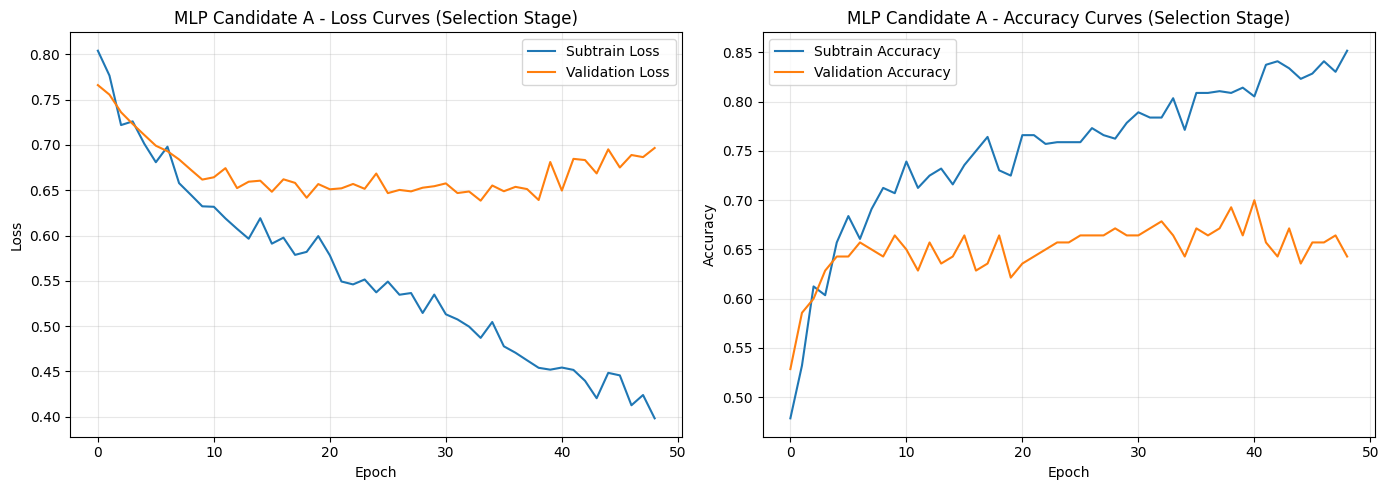

Best epoch selected from validation loss: 34
Note: these curves come from the subtrain/validation model-selection stage, not the final full-train refit.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves from subtrain/validation stage
axes[0].plot(history.history['loss'], label='Subtrain Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title(f'MLP Candidate {best_arch} - Loss Curves (Selection Stage)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves from subtrain/validation stage
axes[1].plot(history.history['accuracy'], label='Subtrain Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title(f'MLP Candidate {best_arch} - Accuracy Curves (Selection Stage)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_mlp_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best epoch selected from validation loss: {best_epoch}')
print('Note: these curves come from the subtrain/validation model-selection stage, not the final full-train refit.')

11. RANDOM FOREST - HYPERPARAMETER GRID SEARCH

In [54]:
rf_pipeline = Pipeline([
    ('preprocess', clone(preprocessor)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=SEED
    ))
])

param_grid = {
    'model__max_depth': [8, 12, 15],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    n_jobs= 1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV F1 (macro): {grid_search.best_score_:.4f}')

# Show top 5 combinations
cv_df = pd.DataFrame(grid_search.cv_results_)
cv_df_sorted = cv_df.sort_values('rank_test_score')[[
    'param_model__max_depth',
    'param_model__min_samples_split',
    'param_model__min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'mean_train_score'
]].head(5)

cv_df_sorted.columns = [
    'max_depth',
    'min_samples_split',
    'min_samples_leaf',
    'Mean CV F1',
    'Std CV F1',
    'Mean Train F1'
]

print('\nTop 5 hyperparameter combinations:')
display(cv_df_sorted)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5}
Best CV F1 (macro): 0.6958

Top 5 hyperparameter combinations:


,max_depth,min_samples_split,min_samples_leaf,Mean CV F1,Std CV F1,Mean Train F1
2,8,5,4,0.695809,0.061217,0.848723
10,15,5,4,0.694899,0.052766,0.880999
0,8,5,2,0.691489,0.031971,0.901790
6,12,5,4,0.690199,0.044776,0.880100
8,15,5,2,0.688143,0.042494,0.965427


12. RANDOM FOREST - BEST MODEL & FEATURE IMPORTANCE

In [55]:
rf_final = grid_search.best_estimator_

# Permutation importance on RAW test data
perm_result = permutation_importance(
    rf_final,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring='f1_macro'
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print('Feature importance (original feature level, permutation importance):')
display(perm_df)

Feature importance (original feature level, permutation importance):


,feature,importance_mean,importance_std
0,checking_balance,0.104093,0.030284
1,months_loan_duration,0.066600,0.020334
4,amount,0.019510,0.009761
2,credit_history,0.017118,0.006767
5,savings_balance,0.010528,0.011987
3,purpose,0.009171,0.012332
7,percent_of_income,0.007613,0.009011
10,other_credit,0.003648,0.005828
15,phone,0.003599,0.002926
14,dependents,0.003498,0.003276


13. MLP - TEST SET EVALUATION

In [56]:
y_pred_mlp_prob = mlp_final.predict(X_test_processed, verbose=0)
y_pred_mlp = np.argmax(y_pred_mlp_prob, axis=1)

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
tn, fp, fn, tp = cm_mlp.ravel()

print('=== MLP Test Set Results ===')
print(f'Confusion Matrix:\n{cm_mlp}')
print(f'\nTN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'\nF1 (macro):          {f1_score(y_test, y_pred_mlp, average="macro"):.4f}')
print(f'Recall (default=yes): {recall_score(y_test, y_pred_mlp, pos_label=1):.4f}')
print(f'Precision (default=yes): {precision_score(y_test, y_pred_mlp, pos_label=1, zero_division=0):.4f}')
print(f'Balanced Accuracy:   {balanced_accuracy_score(y_test, y_pred_mlp):.4f}')
print(f'Accuracy:            {accuracy_score(y_test, y_pred_mlp):.4f}')
print(f'\nClassification Report:')
print(classification_report(
    y_test, y_pred_mlp,
    target_names=['no (0)', 'yes (1)'],
    zero_division=0
))

=== MLP Test Set Results ===
Confusion Matrix:
[[148  62]
 [ 28  62]]

TN=148, FP=62, FN=28, TP=62

F1 (macro):          0.6731
Recall (default=yes): 0.6889
Precision (default=yes): 0.5000
Balanced Accuracy:   0.6968
Accuracy:            0.7000

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.84      0.70      0.77       210
     yes (1)       0.50      0.69      0.58        90

    accuracy                           0.70       300
   macro avg       0.67      0.70      0.67       300
weighted avg       0.74      0.70      0.71       300



14. RANDOM FOREST - TEST SET EVALUATION

In [57]:
y_pred_rf = rf_final.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print('=== Random Forest Test Set Results ===')
print(f'Confusion Matrix:\n{cm_rf}')
print(f'\nTN={tn_rf}, FP={fp_rf}, FN={fn_rf}, TP={tp_rf}')
print(f'\nF1 (macro):          {f1_score(y_test, y_pred_rf, average="macro"):.4f}')
print(f'Recall (default=yes): {recall_score(y_test, y_pred_rf, pos_label=1):.4f}')
print(f'Precision (default=yes): {precision_score(y_test, y_pred_rf, pos_label=1,
                                                  zero_division=0):.4f}')
print(f'Balanced Accuracy:   {balanced_accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Accuracy:            {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'\nClassification Report:')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['no (0)', 'yes (1)'],
    zero_division=0
))

=== Random Forest Test Set Results ===
Confusion Matrix:
[[167  43]
 [ 31  59]]

TN=167, FP=43, FN=31, TP=59

F1 (macro):          0.7166
Recall (default=yes): 0.6556
Precision (default=yes): 0.5784
Balanced Accuracy:   0.7254
Accuracy:            0.7533

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.84      0.80      0.82       210
     yes (1)       0.58      0.66      0.61        90

    accuracy                           0.75       300
   macro avg       0.71      0.73      0.72       300
weighted avg       0.76      0.75      0.76       300



15. MODEL COMPARISON - RESULTS TABLE

In [58]:
comparison = pd.DataFrame({
    'Metric': ['F1 (macro)', 'Recall (yes)', 'Precision (yes)',
               'Balanced Accuracy', 'Accuracy',
               'True Positives', 'False Negatives', 'False Positives', 'True Negatives'],
    'MLP': [
        f1_score(y_test, y_pred_mlp, average='macro'),
        recall_score(y_test, y_pred_mlp, pos_label=1),
        precision_score(y_test, y_pred_mlp, pos_label=1, zero_division=0),
        balanced_accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_mlp),
        tp, fn, fp, tn
    ],
    'Random Forest': [
        f1_score(y_test, y_pred_rf, average='macro'),
        recall_score(y_test, y_pred_rf, pos_label=1),
        precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0),
        balanced_accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf),
        tp_rf, fn_rf, fp_rf, tn_rf
    ]
})

# Format numeric rows to 4 decimal places
for col in ['MLP', 'Random Forest']:
    comparison[col] = comparison.apply(
        lambda row: f"{row[col]:.4f}" if isinstance(row[col], float) else str(int(row[col])), axis=1
    )

print('=== Model Comparison ===')
display(comparison)

=== Model Comparison ===


,Metric,MLP,Random Forest
0,F1 (macro),0.6731,0.7166
1,Recall (yes),0.6889,0.6556
2,Precision (yes),0.5000,0.5784
3,Balanced Accuracy,0.6968,0.7254
4,Accuracy,0.7000,0.7533
5,True Positives,62.0000,59.0000
6,False Negatives,28.0000,31.0000
7,False Positives,62.0000,43.0000
8,True Negatives,148.0000,167.0000


16. CONFUSION MATRICES VISUALIZATION (SIDE-BY-SIDE)

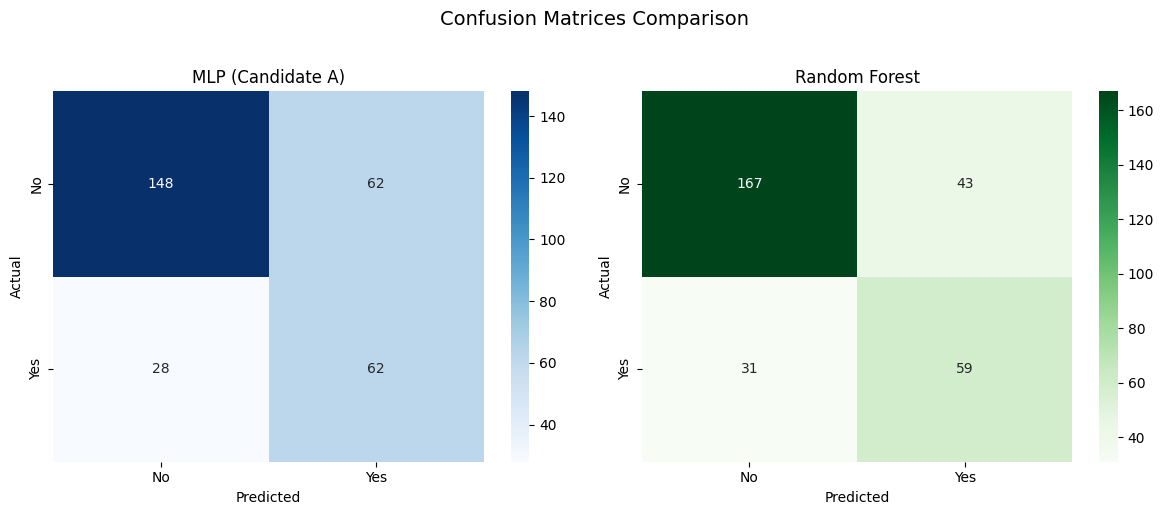

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MLP confusion matrix
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'MLP (Candidate {best_arch})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# RF confusion matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

17. RF FEATURE IMPORTANCE VISUALIZATION

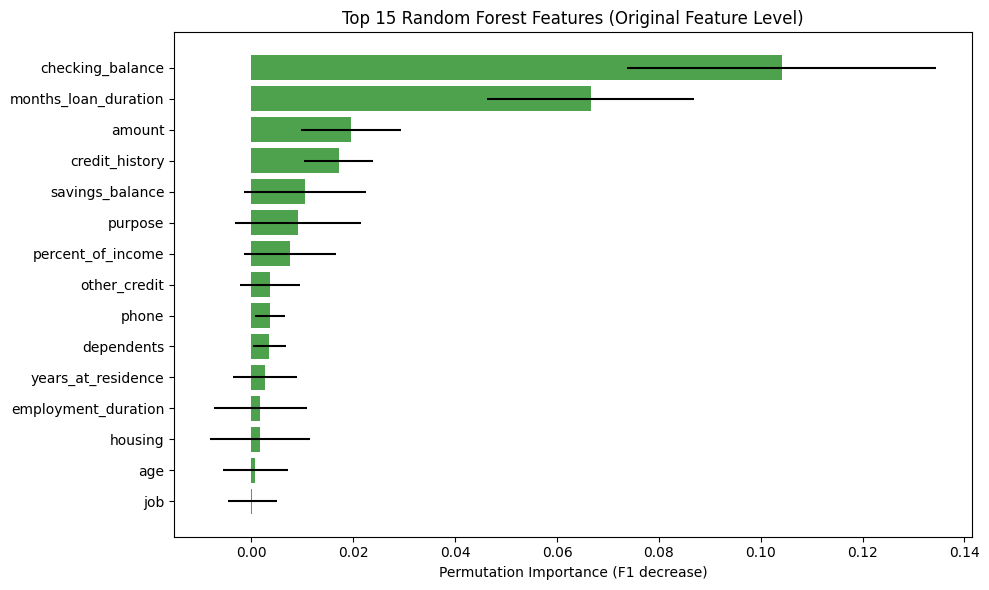

In [60]:
top_features = perm_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    range(len(top_features)),
    top_features['importance_mean'].values,
    xerr=top_features['importance_std'].values,
    color='forestgreen',
    alpha=0.8
)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Permutation Importance (F1 decrease)')
ax.set_title('Top 15 Random Forest Features (Original Feature Level)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

18. RF COMPLEXITY ANALYSIS - CV F1 BY MAX_DEPTH

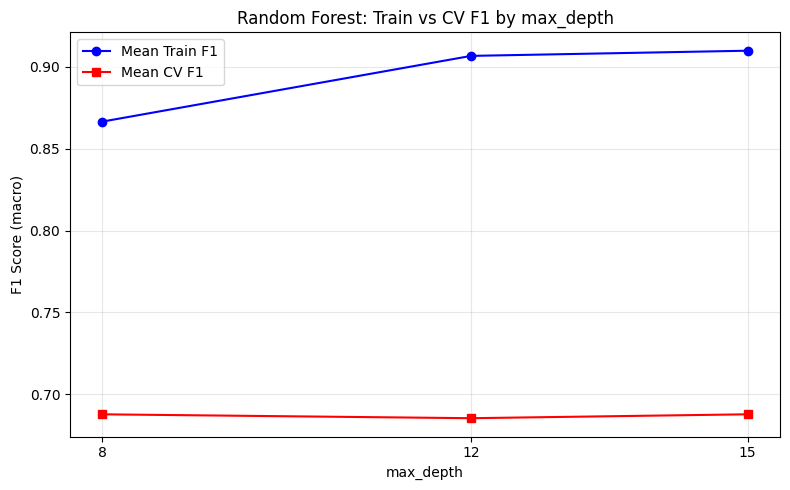

Depth Analysis:


,max_depth,mean_test_score,mean_train_score
0,8,0.687595,0.866595
1,12,0.685215,0.906786
2,15,0.687605,0.909952


In [61]:
cv_full = pd.DataFrame(grid_search.cv_results_)

depth_analysis = cv_full.groupby('param_model__max_depth').agg({
    'mean_test_score': 'mean',
    'mean_train_score': 'mean'
}).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    depth_analysis['param_model__max_depth'],
    depth_analysis['mean_train_score'],
    'o-',
    label='Mean Train F1',
    color='blue'
)
ax.plot(
    depth_analysis['param_model__max_depth'],
    depth_analysis['mean_test_score'],
    's-',
    label='Mean CV F1',
    color='red'
)

ax.set_xlabel('max_depth')
ax.set_ylabel('F1 Score (macro)')
ax.set_title('Random Forest: Train vs CV F1 by max_depth')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(depth_analysis['param_model__max_depth'].values)

plt.tight_layout()
plt.savefig('fig5_rf_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Depth Analysis:')
display(depth_analysis.rename(columns={'param_model__max_depth': 'max_depth'}))

19. BUSINESS COST ANALYSIS

=== Business Cost Analysis ===
Cost assumptions: FN = 3000 DM, FP = 500 DM

MLP:  FN=28, FP=62 -> Total Cost = 28×3000 + 62×500 = 115,000 DM
RF:   FN=31, FP=43 -> Total Cost = 31×3000 + 43×500 = 114,500 DM

Cost difference: 500 DM
Lower cost model: Random Forest


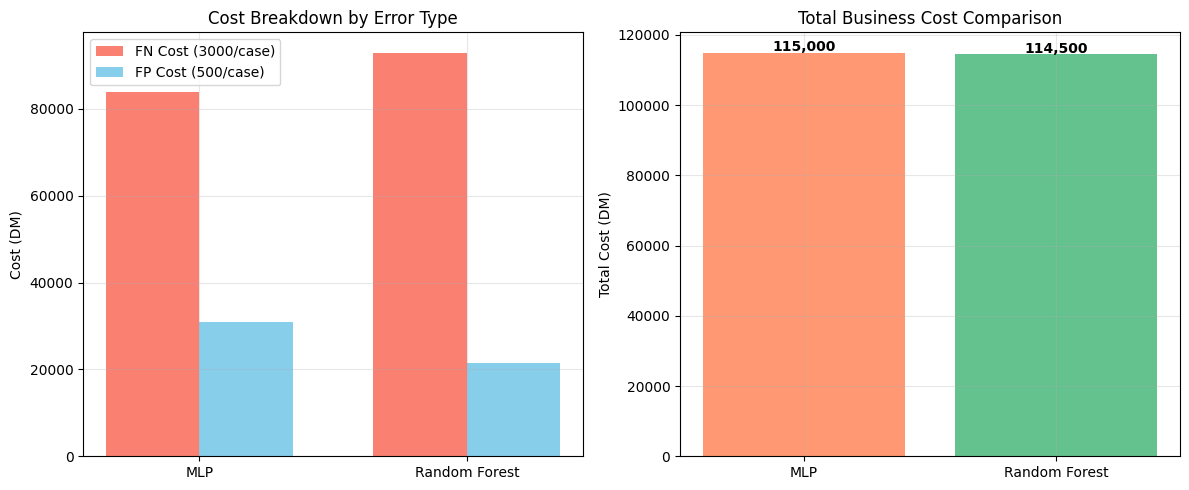

In [62]:
# Hypothetical costs (in DM or arbitrary units)
cost_fn = 3000   # Cost of missing a defaulter (False Negative)
cost_fp = 500    # Cost of rejecting a good customer (False Positive)

# MLP costs
mlp_total_cost = fn * cost_fn + fp * cost_fp
# RF costs
rf_total_cost = fn_rf * cost_fn + fp_rf * cost_fp

print('=== Business Cost Analysis ===')
print(f'Cost assumptions: FN = {cost_fn} DM, FP = {cost_fp} DM')
print(f'\nMLP:  FN={fn}, FP={fp} -> Total Cost = {fn}×{cost_fn} + {fp}×{cost_fp} = {mlp_total_cost:,} DM')
print(f'RF:   FN={fn_rf}, FP={fp_rf} -> Total Cost = {fn_rf}×{cost_fn} + {fp_rf}×{cost_fp} = {rf_total_cost:,} DM')
print(f'\nCost difference: {abs(mlp_total_cost - rf_total_cost):,} DM')
print(f'Lower cost model: {"MLP" if mlp_total_cost < rf_total_cost else "Random Forest"}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cost breakdown
models = ['MLP', 'Random Forest']
fn_costs = [fn * cost_fn, fn_rf * cost_fn]
fp_costs = [fp * cost_fp, fp_rf * cost_fp]

x = np.arange(len(models))
width = 0.35
axes[0].bar(x - width/2, fn_costs, width, label=f'FN Cost ({cost_fn}/case)', color='salmon')
axes[0].bar(x + width/2, fp_costs, width, label=f'FP Cost ({cost_fp}/case)', color='skyblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Cost (DM)')
axes[0].set_title('Cost Breakdown by Error Type')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Total cost comparison
total_costs = [mlp_total_cost, rf_total_cost]
colors = ['coral', 'mediumseagreen']
axes[1].bar(models, total_costs, color=colors, alpha=0.8)
for i, v in enumerate(total_costs):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_ylabel('Total Cost (DM)')
axes[1].set_title('Total Business Cost Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

20. THRESHOLD ANALYSIS - MLP & RF

In [63]:
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np

thresholds = [0.3, 0.4, 0.5, 0.6]

print('=== Threshold Analysis ===')
print(f'\n{"Threshold":<12} {"Model":<16} {"Recall(yes)":<14} {"Precision(yes)":<16} {"F1 macro"}')
print('-' * 65)

# MLP: get probability for class 1
y_prob_mlp = mlp_final.predict(X_test_processed, verbose=0)[:, 1]

# RF: get probability for class 1
y_prob_rf = rf_final.predict_proba(X_test)[:, 1]

for thresh in thresholds:
    # MLP predictions at threshold
    y_pred_mlp_t = (y_prob_mlp >= thresh).astype(int)
    rec_mlp  = recall_score(y_test, y_pred_mlp_t, pos_label=1, zero_division=0)
    prec_mlp = precision_score(y_test, y_pred_mlp_t, pos_label=1, zero_division=0)
    f1_mlp   = f1_score(y_test, y_pred_mlp_t, average='macro', zero_division=0)

    # RF predictions at threshold
    y_pred_rf_t = (y_prob_rf >= thresh).astype(int)
    rec_rf  = recall_score(y_test, y_pred_rf_t, pos_label=1, zero_division=0)
    prec_rf = precision_score(y_test, y_pred_rf_t, pos_label=1, zero_division=0)
    f1_rf   = f1_score(y_test, y_pred_rf_t, average='macro', zero_division=0)

    print(f'{thresh:<12} {"MLP":<16} {rec_mlp:<14.4f} {prec_mlp:<16.4f} {f1_mlp:.4f}')
    print(f'{"":<12} {"Random Forest":<16} {rec_rf:<14.4f} {prec_rf:<16.4f} {f1_rf:.4f}')
    print()

=== Threshold Analysis ===

Threshold    Model            Recall(yes)    Precision(yes)   F1 macro
-----------------------------------------------------------------
0.3          MLP              0.8222         0.4512           0.6382
             Random Forest    0.9111         0.4000           0.5632

0.4          MLP              0.7556         0.4857           0.6686
             Random Forest    0.8333         0.4717           0.6602

0.5          MLP              0.6889         0.5000           0.6731
             Random Forest    0.6556         0.5784           0.7166

0.6          MLP              0.5778         0.5361           0.6776
             Random Forest    0.3778         0.6296           0.6528



21. SUMMARY & FINAL COMPARISON

In [64]:
print('=' * 60)
print('TASK 1 - FINAL SUMMARY')
print('=' * 60)

print(f'\n--- Data ---')
print(f'Samples: 1000 | Features: 16 | Classes: 2 (no=700, yes=300)')
print(f'Split: Stratified 70/30 | CV: Stratified 5-fold')

print(f'\n--- MLP (Candidate {best_arch}) ---')
print(f'CV F1: {max(mean_a, mean_b):.4f}')
print(f'Test F1 (macro): {f1_score(y_test, y_pred_mlp, average="macro"):.4f}')
print(f'Test Recall (yes): {recall_score(y_test, y_pred_mlp, pos_label=1):.4f}')
print(f'Test Precision (yes): {precision_score(y_test, y_pred_mlp,
                                               pos_label=1, zero_division=0):.4f}')
print(f'Business Cost: {mlp_total_cost:,} DM')

print(f'\n--- Random Forest ---')
print(f'Best params: {grid_search.best_params_}')
print(f'CV F1: {grid_search.best_score_:.4f}')
print(f'Test F1 (macro): {f1_score(y_test, y_pred_rf, average="macro"):.4f}')
print(f'Test Recall (yes): {recall_score(y_test, y_pred_rf, pos_label=1):.4f}')
print(f'Test Precision (yes): {precision_score(y_test, y_pred_rf,
                                               pos_label=1, zero_division=0):.4f}')
print(f'Business Cost: {rf_total_cost:,} DM')

print(f'\n--- Top 5 Most Important Features (RF, permutation) ---')
for _, row in perm_df.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance_mean']:.4f}")

print(f'\n--- Key Observations ---')
print('1. Both models handle class imbalance using balanced class weights.')
print('2. Recall for default=yes is the business-critical metric because false negatives are more costly than false positives.')
print('3. Random Forest offers stronger interpretability through permutation feature importance.')
print('4. The final comparison should consider overall F1, recall for default=yes, precision, and business cost together.')

# Result-driven neutral summary
mlp_f1 = f1_score(y_test, y_pred_mlp, average="macro")
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")

mlp_recall_yes = recall_score(y_test, y_pred_mlp, pos_label=1)
rf_recall_yes = recall_score(y_test, y_pred_rf, pos_label=1)

if mlp_recall_yes > rf_recall_yes:
    recall_note = 'MLP detects more actual defaulters on the test set.'
elif rf_recall_yes > mlp_recall_yes:
    recall_note = 'Random Forest detects more actual defaulters on the test set.'
else:
    recall_note = 'Both models achieve the same recall for the default=yes class.'

if mlp_f1 > rf_f1:
    f1_note = 'MLP achieves the higher overall macro F1 score.'
elif rf_f1 > mlp_f1:
    f1_note = 'Random Forest achieves the higher overall macro F1 score.'
else:
    f1_note = 'Both models achieve the same macro F1 score.'

if mlp_total_cost < rf_total_cost:
    cost_note = 'MLP leads to the lower business cost under the assumed cost matrix.'
elif rf_total_cost < mlp_total_cost:
    cost_note = 'Random Forest leads to the lower business cost under the assumed cost matrix.'
else:
    cost_note = 'Both models lead to the same business cost under the assumed cost matrix.'

print(f'5. {f1_note}')
print(f'6. {recall_note}')
print(f'7. {cost_note}')
print('8. The preferred model therefore depends on whether the priority is overall balance, default detection, interpretability, or estimated business cost.')

TASK 1 - FINAL SUMMARY

--- Data ---
Samples: 1000 | Features: 16 | Classes: 2 (no=700, yes=300)
Split: Stratified 70/30 | CV: Stratified 5-fold

--- MLP (Candidate A) ---
CV F1: 0.6825
Test F1 (macro): 0.6731
Test Recall (yes): 0.6889
Test Precision (yes): 0.5000
Business Cost: 115,000 DM

--- Random Forest ---
Best params: {'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5}
CV F1: 0.6958
Test F1 (macro): 0.7166
Test Recall (yes): 0.6556
Test Precision (yes): 0.5784
Business Cost: 114,500 DM

--- Top 5 Most Important Features (RF, permutation) ---
  checking_balance: 0.1041
  months_loan_duration: 0.0666
  amount: 0.0195
  credit_history: 0.0171
  savings_balance: 0.0105

--- Key Observations ---
1. Both models handle class imbalance using balanced class weights.
2. Recall for default=yes is the business-critical metric because false negatives are more costly than false positives.
3. Random Forest offers stronger interpretability through permutation fe